# Specialized plots

Abundance, statistics, palettes, heatmaps, and immune repertoire

These examples collect plot families that complement the full analysis
workflows: donor-aware abundance and pseudobulk summaries from human
pancreas, significance annotations in mouse brain data, differential-
expression visualizations from the rice experiment, and
immune-repertoire plots from ECCITE-seq TCR data. The page also covers
palettes and Marsilea heatmaps.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg
from plotnine import theme_bw, theme, labs, element_text

## Baron pancreas: abundance, composition, and pseudobulk

In [2]:
from data import load_baron

baron = load_baron()
baron.shape

(20125, 8569)

### Abundance by donor and cell type

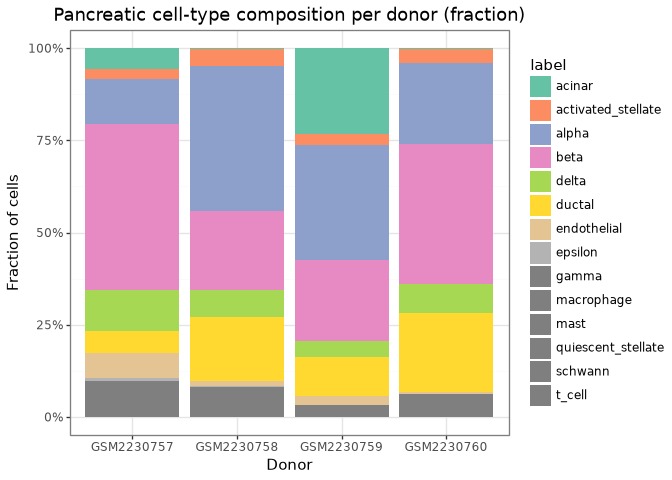

In [3]:
baron_cd = baron.get_column_data().to_pandas()
gg.plot_abundance(baron_cd, group_by="donor", color_by="label") + theme_bw() + labs(title="Pancreatic cell-type composition per donor (fraction)", x="Donor", y="Fraction of cells")

### Counts vs. proportions

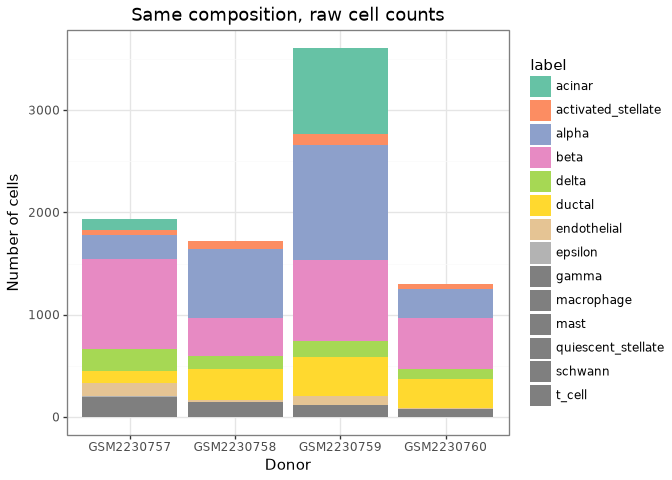

In [4]:
gg.plot_abundance(baron_cd, group_by="donor", color_by="label", normalize=False) + theme_bw() + labs(title="Same composition, raw cell counts", x="Donor", y="Number of cells")

### Donor-aware grouping and pseudobulk QC

Individual cells are not biological replicates. For sample-aware
summaries, the donor identifies the replicate and `label` identifies the
cell type. `plot_pseudobulk_qc` displays cell counts for each
donor/group combination, library sizes, and a pseudobulk PCA across the
four donors:

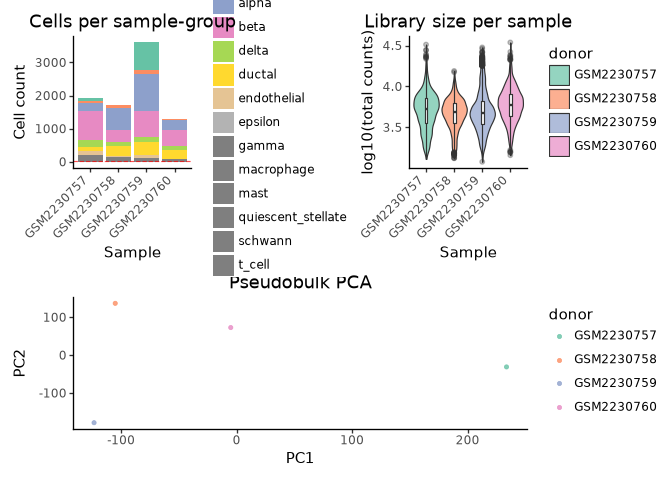

In [5]:
gg.plot_pseudobulk_qc(baron, sample_by="donor", group_by="label", min_cells=10)

### Grouped, clustered heatmap

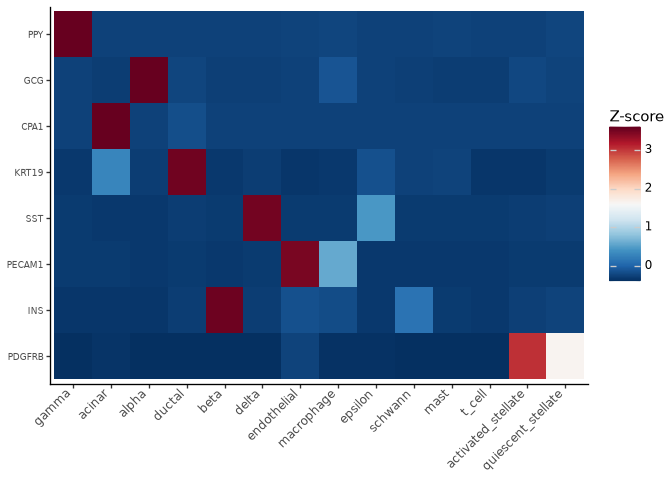

In [6]:
markers = ["INS", "GCG", "SST", "PPY", "KRT19", "CPA1", "PDGFRB", "PECAM1"]
row_names = baron.get_row_names()
available = [m for m in markers if m in row_names]
gg.plot_heatmap(baron, features=available, group_by="label", layer="counts", cluster_rows=True, cluster_cols=True) + theme(axis_text_x=element_text(rotation=45, hjust=1))

## Zeisel: statistics, significance brackets, dot plots, palettes

We use the processed Zeisel object from the [scranpy
workflow](single-cell-scranpy.ipynb):

In [7]:
from data import run_scranpy_pipeline_on_zeisel

final = run_scranpy_pipeline_on_zeisel()

### Grouped statistics with automatic significance brackets

`plot_violin_stats` and `plot_box_stats` can run pairwise tests and add
ggsignif-style brackets. The examples below use the default Mann–Whitney
test across cells. These p-values describe the profiled cells and should
not be interpreted as inference across independent animals; a
biological-replicate analysis would require sample-level observations.

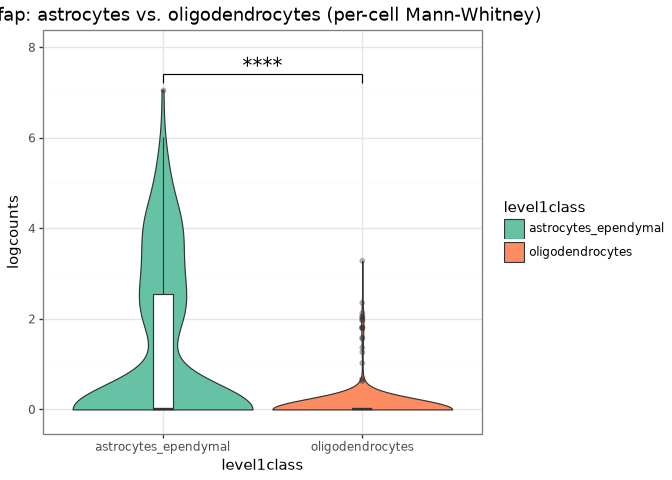

In [8]:
cd = final.column_data.to_pandas()
gfap_idx = list(final.get_row_names()).index("Gfap")
cd["Gfap"] = np.asarray(final.get_assay("logcounts")[gfap_idx, :]).ravel()
two_classes = cd[cd["level1class"].isin(["astrocytes_ependymal", "oligodendrocytes"])]

gg.plot_violin_stats(
    two_classes, "Gfap", group_by="level1class",
    comparisons=[("astrocytes_ependymal", "oligodendrocytes")],
    annotation="stars",
) + theme_bw() + labs(title="Gfap: astrocytes vs. oligodendrocytes (per-cell Mann-Whitney)", y="logcounts")

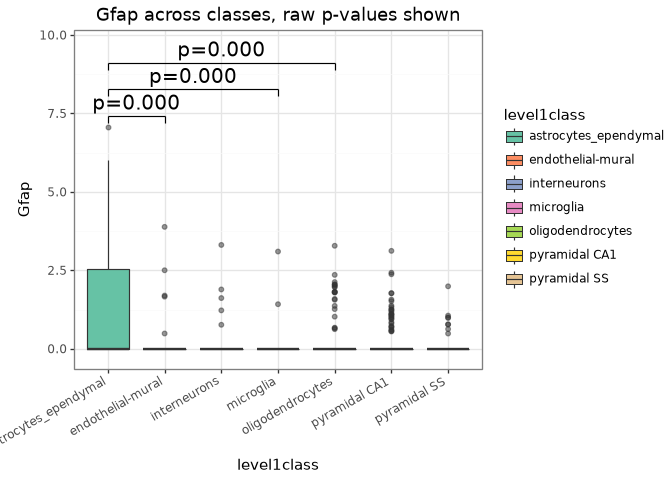

In [9]:
gg.plot_box_stats(
    cd, "Gfap", group_by="level1class",
    comparisons=[("astrocytes_ependymal", c) for c in ["oligodendrocytes", "microglia", "endothelial-mural"]],
    annotation="pvalue", sig_only=False,
) + theme_bw() + theme(axis_text_x=element_text(rotation=30, hjust=1)) + labs(title="Gfap across classes, raw p-values shown")

### A minimal geometry example for `geom_signif`

The next example focuses on bracket placement—stacking, tip length, and
star mapping—using three Zeisel cell classes. It illustrates the
geometry rather than making a biological comparison.

In automatic mode, `geom_signif(comparisons=...)` returns a deferred
`_DeferredSignif` object. Calling `.resolve(df, x_col, y_col)` supplies
the data needed for the tests and returns plotnine layers that can be
added to the plot.

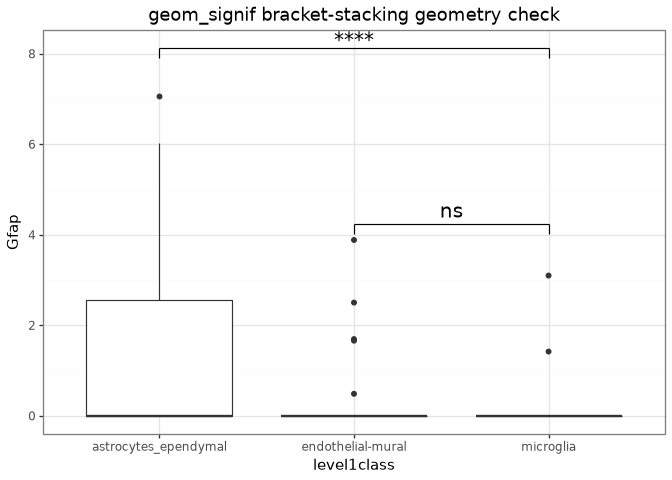

In [10]:
from ggnomics import geom_signif
from plotnine import ggplot, aes, geom_boxplot

geom_df = cd[cd["level1class"].isin(["microglia", "endothelial-mural", "astrocytes_ependymal"])][["level1class", "Gfap"]]
bracket_layers = geom_signif(
    comparisons=[("microglia", "endothelial-mural"), ("microglia", "astrocytes_ependymal")]
).resolve(geom_df, "level1class", "Gfap")

(
    ggplot(geom_df, aes(x="level1class", y="Gfap"))
    + geom_boxplot()
    + bracket_layers
    + theme_bw()
    + labs(title="geom_signif bracket-stacking geometry check")
)

### Dot plot

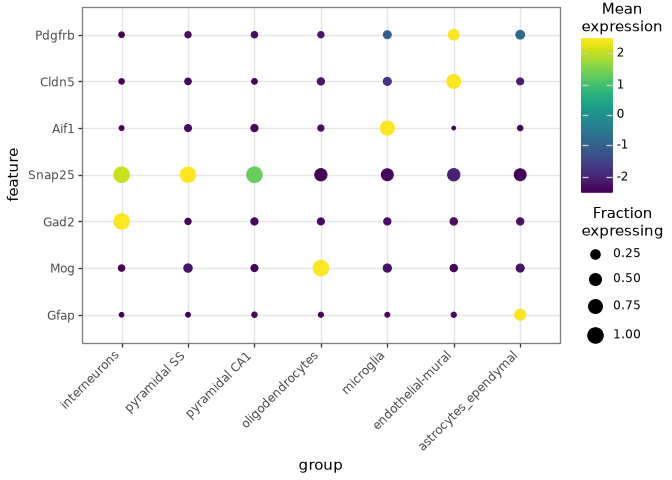

In [11]:
markers = ["Gfap", "Mog", "Gad2", "Snap25", "Aif1", "Cldn5", "Pdgfrb"]
gg.plot_dot(final, features=markers, group_by="level1class", layer="logcounts") + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

### Selected scatter plot

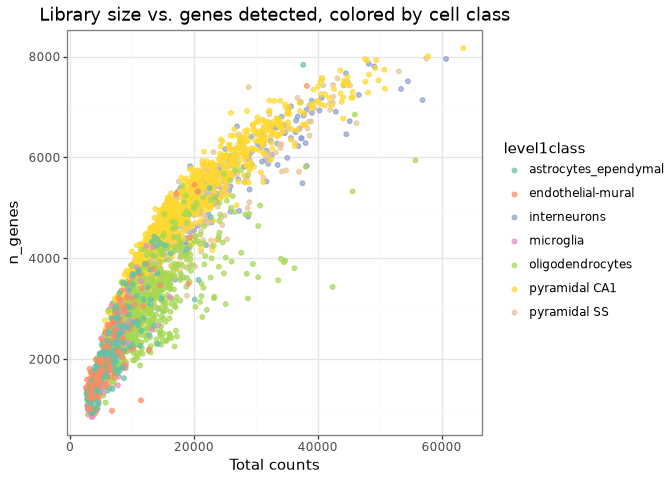

In [12]:
cd["n_genes"] = cd["detected"]
gg.plot_coldata(cd, x="sum", y="n_genes", color_by="level1class") + theme_bw() + labs(title="Library size vs. genes detected, colored by cell class", x="Total counts")

### Custom palettes and the IGV palette

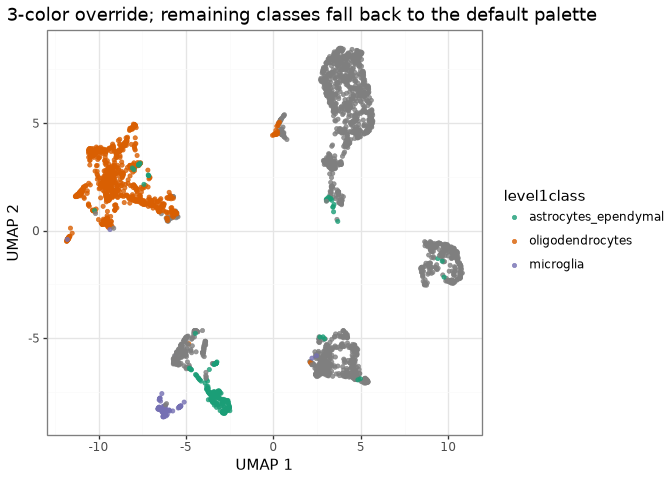

In [13]:
custom = {"astrocytes_ependymal": "#1B9E77", "oligodendrocytes": "#D95F02", "microglia": "#7570B3"}
gg.plot_umap(final, color="level1class", palette=custom) + theme_bw() + labs(title="Custom 3-color override; remaining classes fall back to the default palette")

The IGV palette follows the chromosome-colour convention from the
[Integrative Genomics
Viewer](https://software.broadinstitute.org/software/igv/), using values
published by the R package
[`ggsci`](https://cran.r-project.org/package=ggsci) in
`ggsci::pal_igv()`. See Robinson et al., *Nature Biotechnology* 29,
24–26 (2011).

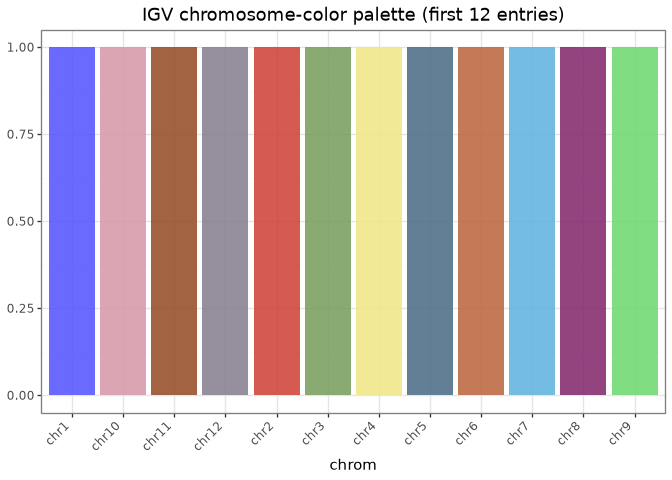

In [14]:
igv_preview = pd.DataFrame({"chrom": list(gg.IGV_DEFAULT.keys())[:12], "value": 1})
gg.plot_coldata(igv_preview, x="chrom", y="value", color_by="chrom", shape="bar", palette=gg.IGV_DEFAULT) + theme_bw() + theme(legend_position="none", axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="IGV chromosome-color palette (first 12 entries)", y="")

## E-MTAB-1625: differential-expression results

The following plots use the PyDESeq2 fit introduced in the [bulk RNA-seq
workflow](bulk-rnaseq.ipynb):

In [15]:
from data import run_deseq2_on_emtab1625

fit = run_deseq2_on_emtab1625()
results, vst, gene_names = fit["results"], fit["vst"], fit["gene_names"]

### Sample metadata plot

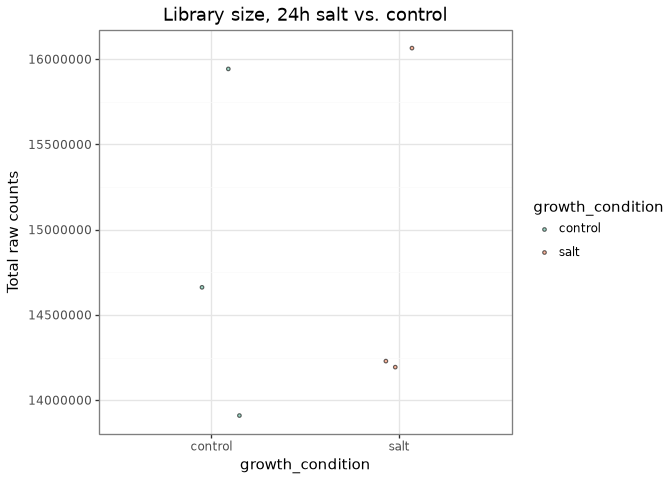

In [16]:
lib_sizes = fit["counts"].sum(axis=1).rename("library_size").reset_index().rename(columns={"index": "sample"})
lib_sizes["growth_condition"] = fit["metadata"]["growth_condition"].to_numpy()
gg.plot_coldata(lib_sizes, x="growth_condition", y="library_size", shape="point") + theme_bw() + labs(title="Library size, 24h salt vs. control", y="Total raw counts")

### Volcano, MA, and coefficient plots — alternate styling

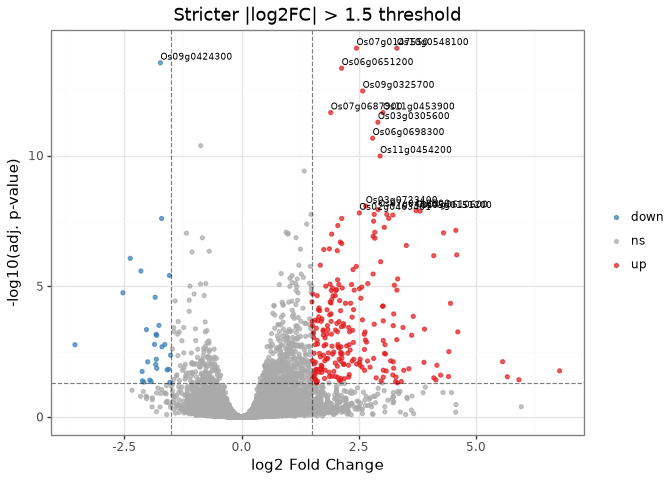

In [17]:
gg.plot_volcano(results, label_top_n=15, logfc_threshold=1.5) + theme_bw() + labs(title="Stricter |log2FC| > 1.5 threshold")

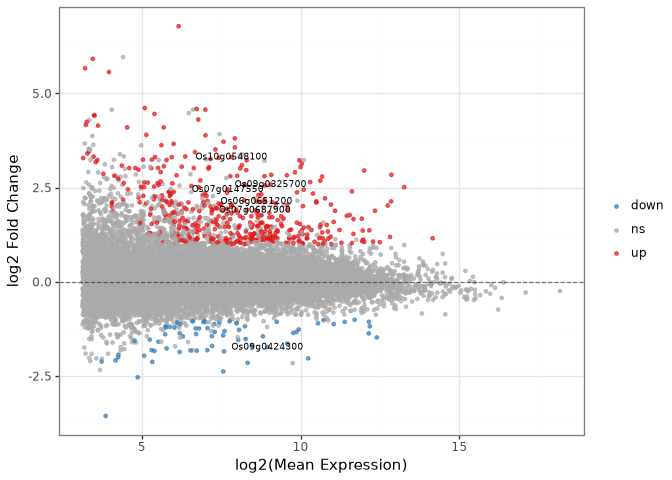

In [18]:
gg.plot_ma(results, label_top_n=6, logfc_threshold=1.0) + theme_bw()

### Marsilea-backed heatmap

The transformed expression matrix can also be passed directly to
[Marsilea](https://marsilea.readthedocs.io/) for a composable heatmap
with dendrograms. Marsilea is used alongside ggnomics here rather than
wrapped by it.

In [19]:
import marsilea as ma

sig_top = results.loc[results["padj"] < 0.05].sort_values("padj").head(25)
mat = vst[sig_top.index]
z = (mat - mat.mean()) / mat.std()
z.columns = [gene_names.get(g) or g for g in z.columns]

h = ma.Heatmap(z.T.to_numpy(), cmap="RdBu_r", label="z-score")
h.add_dendrogram("right")
h.add_dendrogram("top")
h.add_left(ma.plotter.Labels(z.T.index.tolist()), pad=0.1)
h.add_top(ma.plotter.Labels(z.T.columns.tolist()), pad=0.1)
h.render()
h.save(str(pathlib.Path("_freeze_assets") / "marsilea_emtab1625.png"))

<figure>
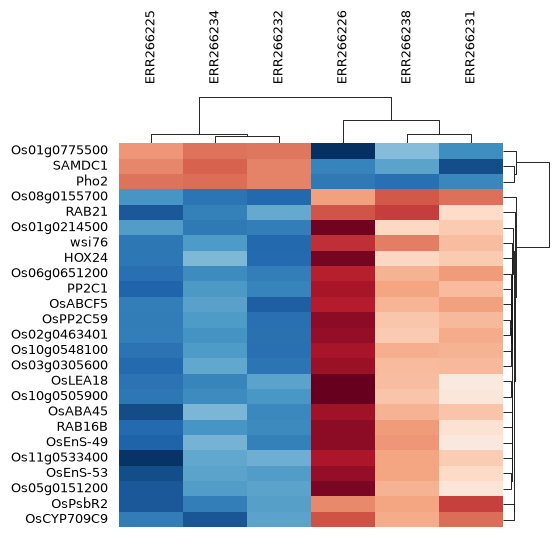
<figcaption aria-hidden="true">Marsilea heatmap of the top 25
significant genes, 24h salt vs. control</figcaption>
</figure>

## ECCITE-seq TCR repertoire (EH4616 CTCL, EH4621 control)

In [20]:
from data import load_tcr_repertoire

tcr = load_tcr_repertoire()
tcr["chain"].value_counts()

Package 'multiassayexperiment' is not installed.

chain
TRB      8581
TRA      6243
Multi    2159
IGL       399
IGH       302
IGK       185
TRG        56
TRD        44
None       16
Name: count, dtype: int64

In [21]:
trb = tcr[(tcr["chain"] == "TRB") & (tcr["raw_clonotype_id"] != "None")].dropna(subset=["v_gene", "j_gene"])
cell_level = trb.drop_duplicates(subset=["barcode", "condition"])
cell_level.shape

(6601, 20)

### Clonotype abundance

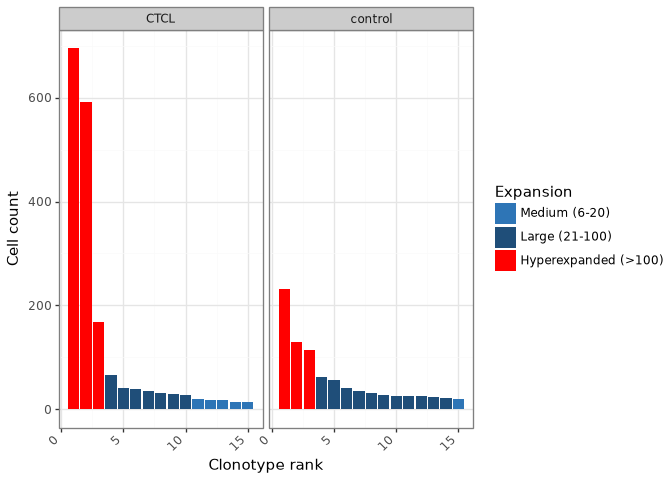

In [22]:
gg.plot_clonotype_abundance(cell_level, clonotype_col="clonotype_id", sample_col="condition", top_n=15) + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1))

### Clonotype overlap

The loading helper prefixes `clonotype_id` by condition because native
10x clonotype labels are only unique within a run. Cross-condition
overlap is therefore calculated from CDR3 amino-acid sequences instead:

In [23]:
productive_trb = tcr[(tcr["chain"] == "TRB") & (tcr["productive"] == "True") & tcr["cdr3"].notna()]
ctcl_cdr3 = set(productive_trb.loc[productive_trb["condition"] == "CTCL", "cdr3"])
control_cdr3 = set(productive_trb.loc[productive_trb["condition"] == "control", "cdr3"])
f"{len(ctcl_cdr3)} unique productive TRB CDR3s (CTCL), {len(control_cdr3)} (control), {len(ctcl_cdr3 & control_cdr3)} shared"

'1568 unique productive TRB CDR3s (CTCL), 1394 (control), 0 shared'

No exact CDR3 sequence is shared between the CTCL and control samples in
these resources. Exact overlap between unrelated individuals is expected
to be sparse because of the diversity of the TCR repertoire. The Jaccard
matrix summarizes the comparison. For more than two groups, a
set-intersection matrix is often more legible than pairwise Jaccard
values — see [UpSet plots](upset.ipynb), which also covers
`plot_pseudobulk_de`’s `mode="upset"`.

In [24]:
cdr3_level = productive_trb.drop_duplicates(subset=["cdr3", "condition"])[["cdr3", "condition"]]
result = gg.plot_clonotype_overlap(cdr3_level, clonotype_col="cdr3", sample_col="condition", method="jaccard")
result.matrix

### V/J gene usage

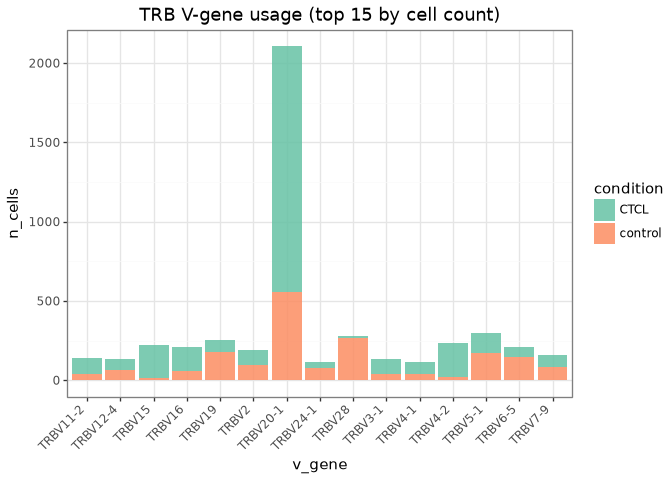

In [25]:
v_usage = cell_level.groupby(["condition", "v_gene"]).size().reset_index(name="n_cells")
top_v = v_usage.groupby("v_gene")["n_cells"].sum().nlargest(15).index
gg.plot_coldata(
    v_usage[v_usage["v_gene"].isin(top_v)], x="v_gene", y="n_cells", color_by="condition", shape="bar",
) + theme_bw() + theme(axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="TRB V-gene usage (top 15 by cell count)")

### Repertoire-feature embedding

These TCR resources do not include matched expression coordinates. We
therefore calculate a repertoire-feature PCA from one-hot-encoded V/J
gene usage per clonotype. It should be interpreted as an embedding of
receptor features, not as a transcriptomic UMAP.

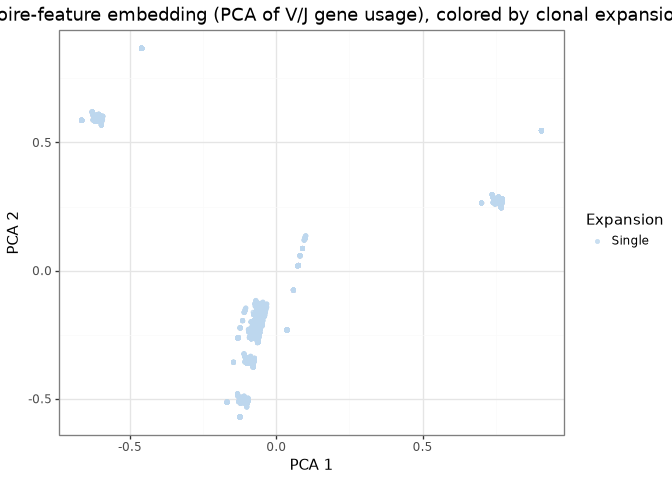

In [26]:
from sklearn.decomposition import PCA

clonotype_summary = (
    trb.groupby("clonotype_id")
    .agg(v_gene=("v_gene", "first"), j_gene=("j_gene", "first"), condition=("condition", "first"), n_cells=("barcode", "nunique"))
    .reset_index()
)
onehot = pd.get_dummies(clonotype_summary[["v_gene", "j_gene"]])
coords = PCA(n_components=2, random_state=0).fit_transform(onehot.to_numpy())
clonotype_summary["X_pca_1"], clonotype_summary["X_pca_2"] = coords[:, 0], coords[:, 1]

gg.plot_clonotype_embedding(clonotype_summary, clonotype_col="clonotype_id", dimred="X_pca") + theme_bw() + labs(title="Repertoire-feature embedding (PCA of V/J gene usage), colored by clonal expansion")

## Composed multi-panel figure

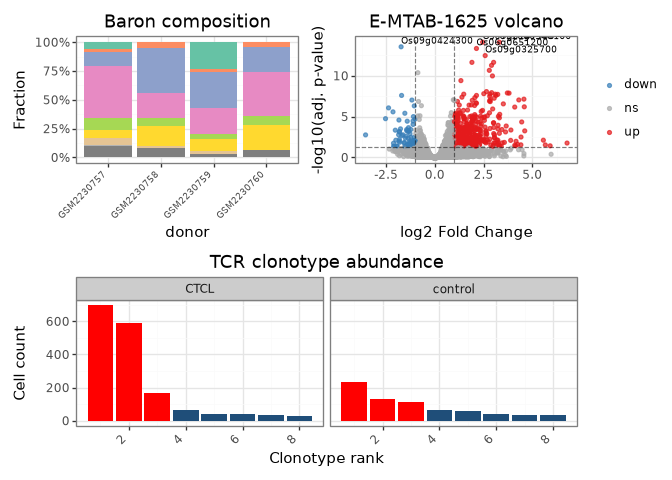

In [27]:
p1 = gg.plot_abundance(baron_cd, group_by="donor", color_by="label") + theme_bw() + theme(legend_position="none", axis_text_x=element_text(rotation=45, hjust=1, size=7)) + labs(title="Baron composition")
p2 = gg.plot_volcano(results, label_top_n=5) + theme_bw() + labs(title="E-MTAB-1625 volcano")
p3 = gg.plot_clonotype_abundance(cell_level, clonotype_col="clonotype_id", sample_col="condition", top_n=8) + theme_bw() + theme(legend_position="none", axis_text_x=element_text(rotation=45, hjust=1)) + labs(title="TCR clonotype abundance")

(p1 | p2) / p3

## Next

- [UpSet plots](upset.ipynb) covers `plot_pseudobulk_de(mode="upset")` and
  the full native set-intersection API in depth.
- The [plot gallery](plot-gallery.ipynb) provides a function-oriented
  index to these and the other plotting examples.